In [48]:
import numpy as np
import pandas as pd
import seaborn as sns

In [49]:
df = pd.read_csv("cell2celltrain.csv")

df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [51]:
df.columns

Index(['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes',
       'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes',
       'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues',
       'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
       'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
       'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
       'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
       'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels',
       'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH',
       'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner',
       'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
       'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGro

In [52]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [53]:
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')


In [54]:
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   MonthlyRevenue             50891 non-null  float64
 2   MonthlyMinutes             50891 non-null  float64
 3   TotalRecurringCharge       50891 non-null  float64
 4   DirectorAssistedCalls      50891 non-null  float64
 5   OverageMinutes             50891 non-null  float64
 6   RoamingCalls               50891 non-null  float64
 7   PercChangeMinutes          50680 non-null  float64
 8   PercChangeRevenues         50680 non-null  float64
 9   DroppedCalls               51047 non-null  float64
 10  BlockedCalls               51047 non-null  float64
 11  UnansweredCalls            51047 non-null  float64
 12  CustomerCareCalls          51047 non-null  float64
 13  ThreewayCalls              51047 non-null  flo

In [55]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Churn                    51047 non-null  object
 1   ServiceArea              51023 non-null  object
 2   ChildrenInHH             51047 non-null  object
 3   HandsetRefurbished       51047 non-null  object
 4   HandsetWebCapable        51047 non-null  object
 5   TruckOwner               51047 non-null  object
 6   RVOwner                  51047 non-null  object
 7   Homeownership            51047 non-null  object
 8   BuysViaMailOrder         51047 non-null  object
 9   RespondsToMailOffers     51047 non-null  object
 10  OptOutMailings           51047 non-null  object
 11  NonUSTravel              51047 non-null  object
 12  OwnsComputer             51047 non-null  object
 13  HasCreditCard            51047 non-null  object
 14  NewCellphoneUser         51047 non-nul

In [56]:
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip().str.title())


In [57]:
df[df["HandsetPrice"]=="Unknown"]

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
28,3000174,Yes,16.14,4.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,6,No,0,Unknown,No,1-Highest,Suburban,Professional,Yes
36,3000230,No,20.18,1.0,20.0,0.00,0.0,0.0,0.0,-0.2,...,0,7,No,0,Unknown,No,1-Highest,Town,Other,No
38,3000238,No,37.99,71.0,38.0,0.00,0.0,0.0,146.0,0.0,...,0,7,No,0,Unknown,No,1-Highest,Other,Other,Yes
43,3000290,No,17.43,20.0,17.0,0.00,1.0,0.0,15.0,1.3,...,0,4,No,0,Unknown,No,4-Medium,Town,Other,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51033,3399882,Yes,38.34,320.0,30.0,0.99,21.0,0.0,-66.0,-8.3,...,0,6,No,0,Unknown,No,1-Highest,Other,Professional,No
51035,3399894,No,0.00,76.0,30.0,0.00,0.0,0.0,0.0,0.0,...,0,4,No,0,Unknown,No,2-High,Other,Professional,No
51037,3399906,No,31.92,63.0,17.0,0.00,43.0,0.0,-38.0,-13.2,...,0,3,No,0,Unknown,No,3-Good,Other,Other,Yes
51039,3399922,No,50.00,492.0,50.0,0.00,0.0,0.0,0.0,0.0,...,0,0,No,0,Unknown,No,6-Verylow,Suburban,Other,Unknown


In [58]:
df["HandsetPrice"] = df["HandsetPrice"].apply(pd.to_numeric, errors='coerce')

In [59]:
df["HandsetPrice"].isna().sum()

np.int64(28982)

In [60]:
df["HandsetPrice"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 51047 entries, 0 to 51046
Series name: HandsetPrice
Non-Null Count  Dtype  
--------------  -----  
22065 non-null  float64
dtypes: float64(1)
memory usage: 398.9 KB


KNN IMPUTATION-Avoid on massive datasets, as calculating the distance between all points is computationally expensive and slow. 

In [61]:
df['HandsetPrice'] = df.groupby('IncomeGroup')['HandsetPrice'].transform(
    lambda x: x.fillna(x.median())
)

So this is ordinal ranking of income

In [62]:
print(df["IncomeGroup"].unique())

[4 5 6 9 1 7 3 0 8 2]


In [63]:
print(df["CreditRating"].unique())

['1-Highest' '4-Medium' '3-Good' '6-Verylow' '2-High' '5-Low' '7-Lowest']


In [64]:

df['CreditRating'] = df['CreditRating'].str.extract('(\d+)').astype(int)
df['CreditRating'] = df['CreditRating'].max() + 1 - df['CreditRating']

In [65]:
print(df["CreditRating"].unique())

[7 4 5 2 6 3 1]


In [66]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    51047 non-null  object 
 1   ServiceArea              51023 non-null  object 
 2   ChildrenInHH             51047 non-null  object 
 3   HandsetRefurbished       51047 non-null  object 
 4   HandsetWebCapable        51047 non-null  object 
 5   TruckOwner               51047 non-null  object 
 6   RVOwner                  51047 non-null  object 
 7   Homeownership            51047 non-null  object 
 8   BuysViaMailOrder         51047 non-null  object 
 9   RespondsToMailOffers     51047 non-null  object 
 10  OptOutMailings           51047 non-null  object 
 11  NonUSTravel              51047 non-null  object 
 12  OwnsComputer             51047 non-null  object 
 13  HasCreditCard            51047 non-null  object 
 14  NewCellphoneUser      

In [67]:
df.isna().sum()

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

In [68]:
(df.isnull().any(axis=1).sum() / len(df)) * 100
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

In [69]:
cols_to_drop = [col for col in df.columns if df[col].nunique() <= 1] 
cols_to_drop

[]

In [70]:
df = df.dropna()

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49752 entries, 0 to 51043
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 49752 non-null  int64  
 1   Churn                      49752 non-null  object 
 2   MonthlyRevenue             49752 non-null  float64
 3   MonthlyMinutes             49752 non-null  float64
 4   TotalRecurringCharge       49752 non-null  float64
 5   DirectorAssistedCalls      49752 non-null  float64
 6   OverageMinutes             49752 non-null  float64
 7   RoamingCalls               49752 non-null  float64
 8   PercChangeMinutes          49752 non-null  float64
 9   PercChangeRevenues         49752 non-null  float64
 10  DroppedCalls               49752 non-null  float64
 11  BlockedCalls               49752 non-null  float64
 12  UnansweredCalls            49752 non-null  float64
 13  CustomerCareCalls          49752 non-null  float64


In [72]:
for col in cat_cols:
    print(col,df[col].unique())

Churn ['Yes' 'No']
ServiceArea ['Seapor503' 'Pithom412' 'Milmil414' 'Okctul918' 'Okcokc405' 'Sanmca210'
 'Slcslc801' 'Loulou502' 'Kcykck913' 'Kcynew316' 'Kcykcm816' 'Denden303'
 'Phictr610' 'Okclrk501' 'Omades515' 'Sanaus512' 'Kcywic316' 'Indind317'
 'Slcpro801' 'Omalnc402' 'Nshnsh615' 'Omaoma402' 'Phxtuc520' 'Daldal214'
 'Daldtn940' 'Dalftw817' 'Sansan210' 'Nycman917' 'Nolken504' 'Minmin612'
 'Phiard610' 'Nycque917' 'Denbou303' 'Bosbos617' 'Phxphx602' 'Nnybuf716'
 'Nnysyr315' 'Stlstl314' 'Phiphi215' 'Dettol419' 'Seablv425' 'Miamia305'
 'Phichc215' 'Seasea206' 'Birbir205' 'Miadfd954' 'Lounal812' 'Miadel561'
 'Miaftl954' 'Seaspo509' 'Seatac253' 'Nnyroc716' 'Sfrsac916' 'Mianda305'
 'Minstp612' 'Miahwd954' 'Nycbro917' 'Phijen215' 'Omacdr319' 'Miawpb561'
 'Seaoly360' 'Pitbut412' 'Seaeve425' 'Phimer609' 'Seacda208' 'Harhar860'
 'Sfrsfr415' 'Sfroak510' 'Sfrscl408' 'Nnyalb518' 'Stlcol618' 'Nycnew201'
 'Sfrpal650' 'Detdet313' 'Detros810' 'Nycnew908' 'Nycnas516' 'Nshcol615'
 'Pitgre412' 'Seabea

In [73]:
binary_cols = [
    'ChildrenInHH','HandsetRefurbished','HandsetWebCapable',
    'TruckOwner','RVOwner','BuysViaMailOrder','RespondsToMailOffers',
    'OptOutMailings','NonUSTravel','OwnsComputer','HasCreditCard',
    'NewCellphoneUser','NotNewCellphoneUser','OwnsMotorcycle',
    'MadeCallToRetentionTeam','Churn'
]

df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11136\1338416990.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})


In [74]:
df.drop(columns=['NotNewCellphoneUser','CustomerID'], inplace=True)

In [75]:
df['Homeownership'] = df['Homeownership'].map({'Known':1, 'Unknown':0})

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49752 entries, 0 to 51043
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      49752 non-null  int64  
 1   MonthlyRevenue             49752 non-null  float64
 2   MonthlyMinutes             49752 non-null  float64
 3   TotalRecurringCharge       49752 non-null  float64
 4   DirectorAssistedCalls      49752 non-null  float64
 5   OverageMinutes             49752 non-null  float64
 6   RoamingCalls               49752 non-null  float64
 7   PercChangeMinutes          49752 non-null  float64
 8   PercChangeRevenues         49752 non-null  float64
 9   DroppedCalls               49752 non-null  float64
 10  BlockedCalls               49752 non-null  float64
 11  UnansweredCalls            49752 non-null  float64
 12  CustomerCareCalls          49752 non-null  float64
 13  ThreewayCalls              49752 non-null  float64


In [79]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns


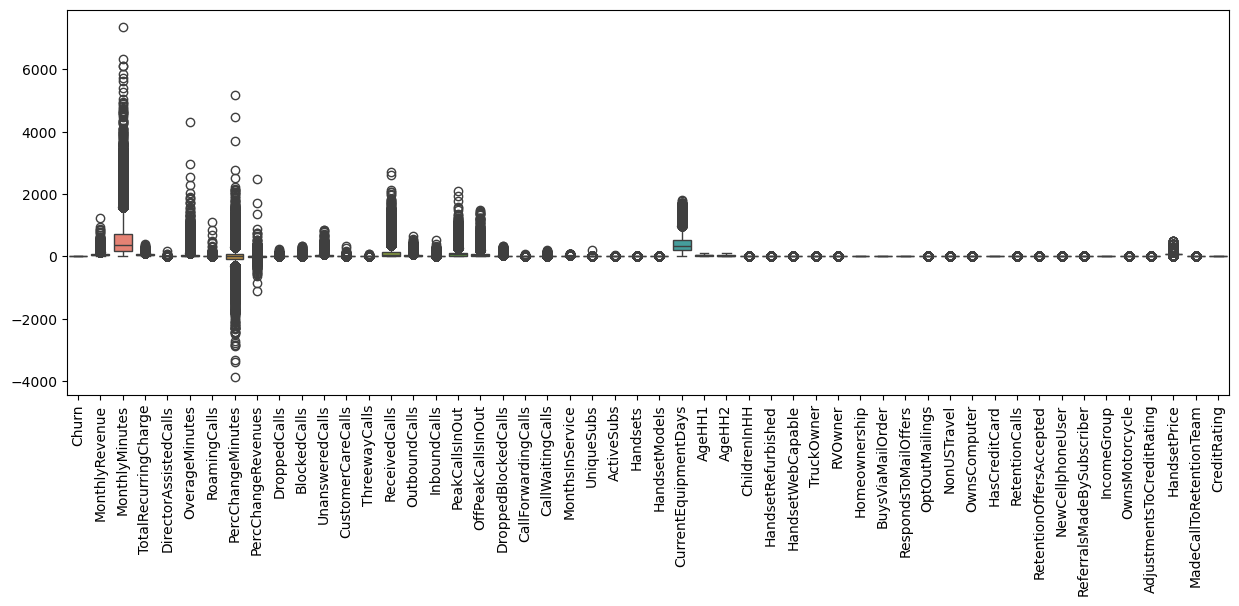

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()


In [81]:
df['TotalCalls'] = df['InboundCalls'] + df['OutboundCalls']
df['MinutesPerCall'] = df['MonthlyMinutes'] / (df['TotalCalls'] + 1)
df['CallsPerDay'] = df['TotalCalls'] / (df['MonthsInService'] + 1)
df['UnansweredRate'] = df['UnansweredCalls'] / (df['TotalCalls'] + 1)
df['FailureRate'] = (df['DroppedCalls'] + df['BlockedCalls']) / (df['TotalCalls'] + 1)
df['CostPerMinute'] = df['MonthlyRevenue'] / (df['MonthlyMinutes'] + 1)
df['OverageRatio'] = df['OverageMinutes'] / (df['MonthlyMinutes'] + 1)
df['ComplaintRate'] = df['CustomerCareCalls'] / (df['TotalCalls'] + 1)
df['RetentionSuccessRate'] = df['RetentionOffersAccepted'] / (df['RetentionCalls'] + 1)
df['RetentionContacted'] = (df['RetentionCalls'] > 0).astype(int)
df.groupby('RetentionContacted')['Churn'].mean()   

RetentionContacted
0    0.281295
1    0.435534
Name: Churn, dtype: float64

In [82]:
corr_matrix = df.corr(numeric_only=True)

In [83]:
corr_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(corr_with_churn)

Churn                      1.000000
CurrentEquipmentDays       0.102513
CostPerMinute              0.071410
MadeCallToRetentionTeam    0.060577
RetentionContacted         0.060577
                             ...   
HandsetModels             -0.040470
OffPeakCallsInOut         -0.040955
MonthlyMinutes            -0.050165
TotalRecurringCharge      -0.058945
HandsetWebCapable         -0.062409
Name: Churn, Length: 62, dtype: float64


In [84]:
corr_df = corr_with_churn.reset_index()
corr_df.columns = ['Feature', 'Correlation_with_Churn']
print(corr_df)

                    Feature  Correlation_with_Churn
0                     Churn                1.000000
1      CurrentEquipmentDays                0.102513
2             CostPerMinute                0.071410
3   MadeCallToRetentionTeam                0.060577
4        RetentionContacted                0.060577
..                      ...                     ...
57            HandsetModels               -0.040470
58        OffPeakCallsInOut               -0.040955
59           MonthlyMinutes               -0.050165
60     TotalRecurringCharge               -0.058945
61        HandsetWebCapable               -0.062409

[62 rows x 2 columns]


In [85]:
corr_df[abs(corr_df['Correlation_with_Churn']) > 0.04]

,Feature,Correlation_with_Churn
0,Churn,1.000000
1,CurrentEquipmentDays,0.102513
2,CostPerMinute,0.071410
3,MadeCallToRetentionTeam,0.060577
4,RetentionContacted,0.060577
5,RetentionCalls,0.058422
6,OverageRatio,0.050311
7,CreditRating,0.047741
57,HandsetModels,-0.040470
58,OffPeakCallsInOut,-0.040955


In [86]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True).abs()

# upper triangle (to avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# get pairs with correlation > 0.8
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.8:
            high_corr_pairs.append((row, col, upper.loc[row, col]))

# print results
for pair in high_corr_pairs:
    print(f"{pair[0]}  <--->  {pair[1]}  =  {pair[2]:.2f}")

MonthlyMinutes  <--->  ReceivedCalls  =  0.83
BlockedCalls  <--->  DroppedBlockedCalls  =  0.81
Handsets  <--->  HandsetModels  =  0.89
BuysViaMailOrder  <--->  RespondsToMailOffers  =  0.97
RetentionCalls  <--->  MadeCallToRetentionTeam  =  0.96
OutboundCalls  <--->  TotalCalls  =  0.97
InboundCalls  <--->  TotalCalls  =  0.87
OutboundCalls  <--->  CallsPerDay  =  0.84
TotalCalls  <--->  CallsPerDay  =  0.86
RetentionOffersAccepted  <--->  RetentionSuccessRate  =  0.98
RetentionCalls  <--->  RetentionContacted  =  0.96
MadeCallToRetentionTeam  <--->  RetentionContacted  =  1.00


In [87]:
df.drop(columns=['TotalCalls','RetentionCalls','MadeCallToRetentionTeam','RetentionOffersAccepted','DroppedCalls','CustomerCareCalls'
                 ,'OverageMinutes','Handsets','BuysViaMailOrder','ReceivedCalls','CallForwardingCalls','ServiceArea'], inplace=True)

df.drop(columns=[
    'MonthlyRevenue',
    'MonthlyMinutes',
    'OutboundCalls',
    'PeakCallsInOut',
    'OffPeakCallsInOut',
    'UniqueSubs',
    'AgeHH2',
    'UnansweredCalls',
    'HasCreditCard'
], inplace=True)

In [88]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,

)

In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [90]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_enc, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [91]:
y_pred = model.predict(X_test_enc)
y_prob = model.predict_proba(X_test_enc)[:,1]

In [92]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.7160084413626772
Recall: 0.07062050051422694
Precision: 0.6417445482866043
F1: 0.1272390364422483


In [93]:
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

import pandas as pd

# Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
   
}

# Sampling techniques
strategies = {
    "Baseline": None,
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SMOTE-ENN": SMOTEENN(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42)
}

results = []

for model_name, model in models.items():
    for strat_name, sampler in strategies.items():

        if sampler is not None:
            X_res, y_res = sampler.fit_resample(X_train_enc, y_train)
        else:
            X_res, y_res = X_train_enc, y_train

        model.fit(X_res, y_res)
        y_pred = model.predict(X_test_enc)

        results.append({
            "Model": model_name,
            "Technique": strat_name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 3),
            "Recall": round(recall_score(y_test, y_pred), 3),
            "Precision": round(precision_score(y_test, y_pred), 3),
            "F1": round(f1_score(y_test, y_pred), 3)
        })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Recall", ascending=False).head(10))

           Model    Technique  Accuracy  Recall  Precision     F1
8  Random Forest    SMOTE-ENN     0.629   0.539      0.401  0.460
3  Decision Tree    SMOTE-ENN     0.594   0.505      0.362  0.422
1  Decision Tree        SMOTE     0.614   0.370      0.350  0.360
2  Decision Tree       ADASYN     0.608   0.363      0.341  0.352
4  Decision Tree  SMOTE-Tomek     0.610   0.358      0.342  0.350
0  Decision Tree     Baseline     0.627   0.354      0.361  0.357
9  Random Forest  SMOTE-Tomek     0.712   0.082      0.560  0.143
7  Random Forest       ADASYN     0.713   0.080      0.570  0.140
6  Random Forest        SMOTE     0.711   0.078      0.548  0.136
5  Random Forest     Baseline     0.716   0.071      0.642  0.127


In [94]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

import pandas as pd

strategies = {
    "Baseline": None,
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42),
    "SMOTE-ENN": SMOTEENN(random_state=42)
}

results = []

for name, sampler in strategies.items():

    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_enc, y_train)
    else:
        X_res, y_res = X_train_enc, y_train

    # 🔥 XGBoost Model
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_enc)

    results.append({
        "Technique": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Recall", ascending=False))

     Technique  Accuracy  Recall  Precision     F1
4    SMOTE-ENN     0.646   0.517      0.416  0.461
1        SMOTE     0.716   0.174      0.549  0.264
0     Baseline     0.716   0.169      0.550  0.258
2       ADASYN     0.715   0.169      0.546  0.258
3  SMOTE-Tomek     0.716   0.169      0.549  0.258
